In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler

In [2]:
df = pd.read_csv("../dataset/hmnist_28_28_RGB.csv")
X = df.iloc[:,:-1]
Y = df.iloc[:,-1]

# Initialize RandomOverSampler
oversample = RandomOverSampler(random_state=42)

# Apply oversampling to balance the dataset
X, Y = oversample.fit_resample(X, Y)

# Convert to numpy arrays
X = X.to_numpy()
Y = Y.to_numpy()

X = X.reshape(-1, 28, 28, 3) #Reshape to original image dimensions (N, 28, 28, 3)


X = np.transpose(X, (0, 3, 1, 2))
X = X / 255.0

# Convert to PyTorch Tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(Y, dtype=torch.long) # In PyTorch, labels must be Long type

# Simple Split (80% train, 20% test) instead of K-Fold
# We use a single split to train one final model for verification
X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [3]:
class SkinCancerCNN(nn.Module):
    def __init__(self):
        super(SkinCancerCNN, self).__init__()
        
        self.features = nn.Sequential(
            # First Convolutional Block
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),              
            nn.MaxPool2d(2, 2),     # Reduces size to 14x14
           
            # Second Convolutional Block
           
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),     # Reduces size to 7x7
            
    
            nn.Flatten()
        )
        
        self.classifier = nn.Sequential(
            # Reduced Dense layers
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.2),        
            nn.Linear(128, 7)       # 7 Output classes
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Initialize model  
model = SkinCancerCNN()

In [4]:
# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Learning Rate Scheduler 
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

train_losses = []
train_accs = []
val_accs = []

EPOCHS = 15 

for epoch in range(EPOCHS):
    model.train() 
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    # Validation phase (at the end of each epoch)
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    val_acc = 100 * val_correct / val_total
    
    scheduler.step(val_acc)
    
    train_acc = 100 * correct / total
    train_losses.append(running_loss / len(train_loader))
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {running_loss/len(train_loader):.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")


Epoch 1/15 | Loss: 1.3676 | Train Acc: 46.05% | Val Acc: 61.20%
Epoch 2/15 | Loss: 0.9449 | Train Acc: 64.21% | Val Acc: 70.67%
Epoch 3/15 | Loss: 0.7401 | Train Acc: 72.38% | Val Acc: 77.78%
Epoch 4/15 | Loss: 0.6102 | Train Acc: 77.21% | Val Acc: 81.87%
Epoch 5/15 | Loss: 0.5101 | Train Acc: 80.86% | Val Acc: 83.74%
Epoch 6/15 | Loss: 0.4326 | Train Acc: 83.89% | Val Acc: 87.61%
Epoch 7/15 | Loss: 0.3703 | Train Acc: 86.10% | Val Acc: 87.87%
Epoch 8/15 | Loss: 0.3307 | Train Acc: 87.46% | Val Acc: 87.83%
Epoch 9/15 | Loss: 0.2922 | Train Acc: 88.93% | Val Acc: 90.01%
Epoch 10/15 | Loss: 0.2584 | Train Acc: 90.27% | Val Acc: 92.29%
Epoch 11/15 | Loss: 0.2381 | Train Acc: 91.00% | Val Acc: 91.73%
Epoch 12/15 | Loss: 0.2225 | Train Acc: 91.67% | Val Acc: 93.09%
Epoch 13/15 | Loss: 0.2029 | Train Acc: 92.25% | Val Acc: 93.69%
Epoch 14/15 | Loss: 0.1864 | Train Acc: 92.98% | Val Acc: 94.12%
Epoch 15/15 | Loss: 0.1748 | Train Acc: 93.53% | Val Acc: 94.84%


In [5]:
torch.save(model.state_dict(), 'skin_model.pth')
print("\n[SUCCESS] Model saved as 'skin_model.pth'")

# Save data for verification 
# (We only save 20 images that the network classifies CORRECTLY)
model.eval()
images_to_verify = []
labels_to_verify = []
count = 0

print("Extracting images for verification...")
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        
        # Filter: keep only if prediction matches label
        correct_mask = (predicted == labels)
        
        if correct_mask.any():
            # Convert to NumPy for saving
            valid_imgs = inputs[correct_mask].numpy()
            valid_lbls = labels[correct_mask].numpy()
            
            for img, lbl in zip(valid_imgs, valid_lbls):
                images_to_verify.append(img)
                labels_to_verify.append(lbl)
                count += 1
                if count >= 20: # We only need 20 examples
                    break
        if count >= 20:
            break

# Save as .npy files for Alpha-Beta-CROWN and Auto-LiRPA
X_verify = np.array(images_to_verify)
Y_verify = np.array(labels_to_verify)

np.save('data_X.npy', X_verify)
np.save('data_Y.npy', Y_verify)

print(f"[SUCCESS] Verification dataset ({count} images) saved as 'data_X.npy' and 'data_Y.npy'")



[SUCCESS] Model saved as 'skin_model.pth'
Extracting images for verification...
[SUCCESS] Verification dataset (20 images) saved as 'data_X.npy' and 'data_Y.npy'


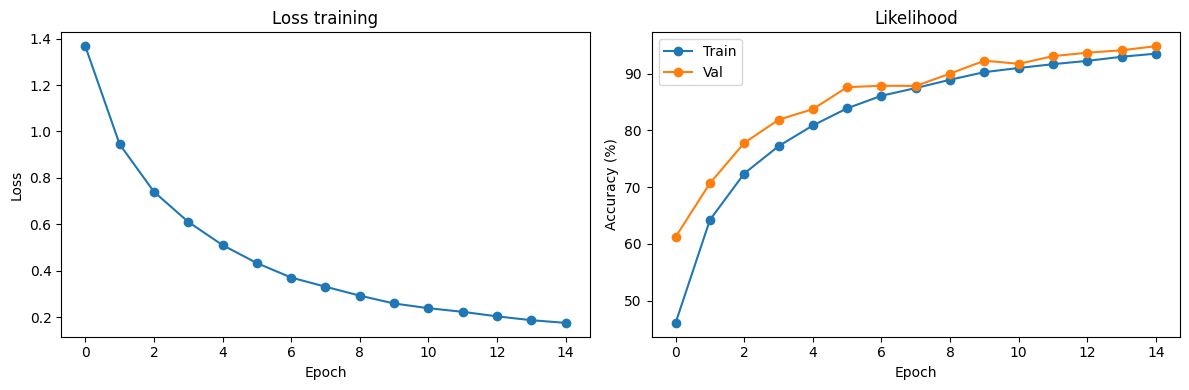

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_losses, marker='o')
plt.title('Loss training')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1,2,2)
plt.plot(train_accs, marker='o', label='Train')
plt.plot(val_accs, marker='o', label='Val')
plt.title('Likelihood')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()


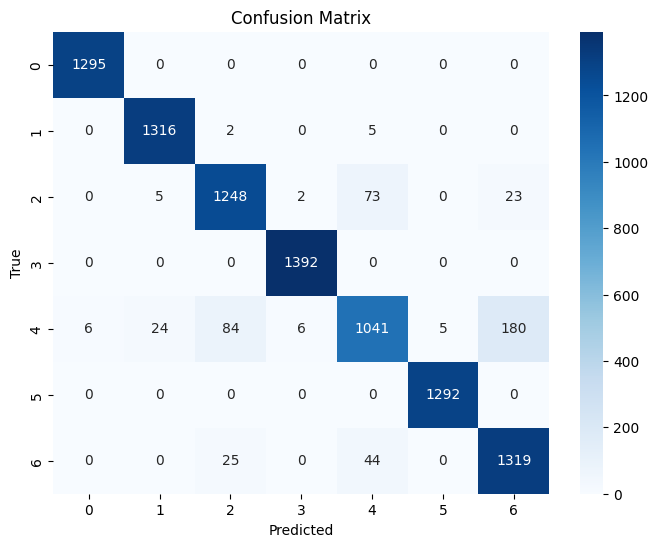

              precision    recall  f1-score   support

           0     0.9954    1.0000    0.9977      1295
           1     0.9784    0.9947    0.9865      1323
           2     0.9183    0.9238    0.9210      1351
           3     0.9943    1.0000    0.9971      1392
           4     0.8951    0.7734    0.8298      1346
           5     0.9961    1.0000    0.9981      1292
           6     0.8666    0.9503    0.9065      1388

    accuracy                         0.9484      9387
   macro avg     0.9492    0.9489    0.9481      9387
weighted avg     0.9484    0.9484    0.9475      9387



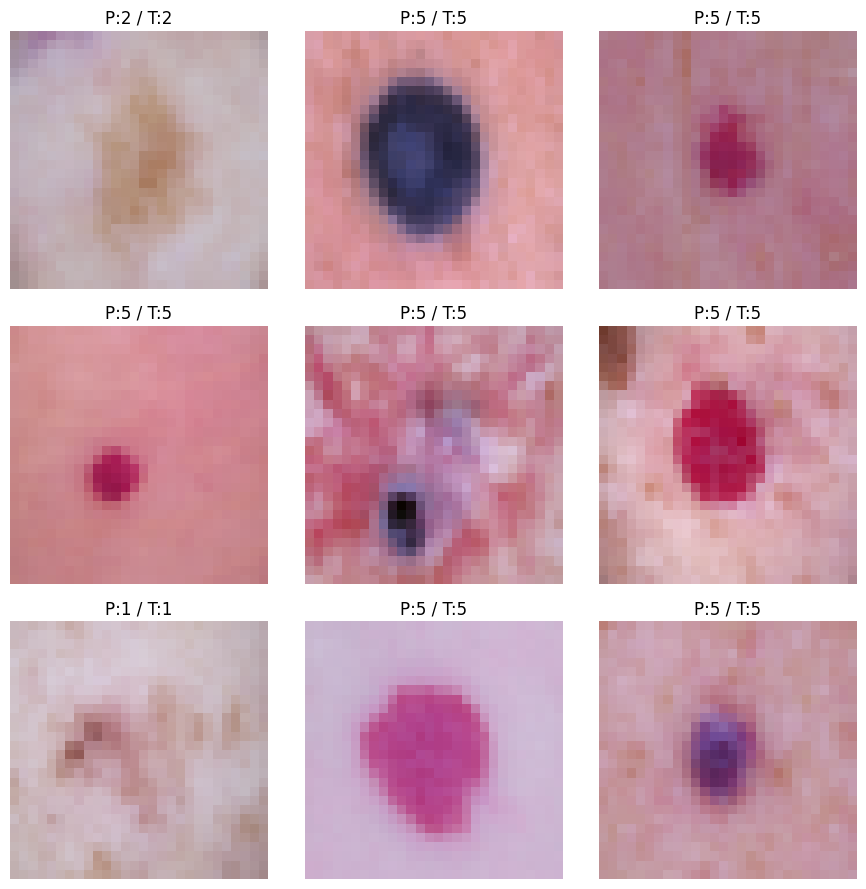

In [9]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.numpy().tolist())
        y_pred.extend(preds.numpy().tolist())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

print(classification_report(y_true, y_pred, digits=4))

def imshow_tensor(img):
    img = img.numpy()
    img = np.transpose(img, (1,2,0))
    plt.imshow(img)
    plt.axis('off')

examples = 9
fig = plt.figure(figsize=(9,9))
idx = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        for i in range(inputs.size(0)):
            if idx >= examples:
                break
            idx += 1
            ax = fig.add_subplot(3,3,idx)
            imshow_tensor(inputs[i])
            _, pred = torch.max(model(inputs[i].unsqueeze(0)), 1)
            ax.set_title(f"P:{pred.item()} / T:{labels[i].item()}")
        if idx >= examples:
            break
plt.tight_layout()
plt.show()